In [1]:
import numpy as np
import itertools
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, roc_curve, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from keras.models import Model, Sequential
from keras.layers import Input, Conv1D, MaxPooling1D, Dense, Dropout, Flatten, Concatenate, LSTM, BatchNormalization, SpatialDropout1D, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.losses import Huber
import os
import random
from scipy import stats
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt 
import xgboost as xgb
from scipy import stats
import shap
from Common_Functions import set_global_determinism, evaluate, \
                                ROC_AUC, CNN_LSTM_Explain, feature_importance, \
                                analyse_profit, analyse_profit, \
                                Prepare_Data, Prepare_Data_XGBoost, \
                                best_threshold,CNN_LSTM_Model, CNN_LSTM_Results, \
                                XGBoost_Results, Meta_Model, feature_importance_table


folder = "exported_csvs"

data = {
    os.path.splitext(f)[0]: pd.read_csv(os.path.join(folder, f))
    for f in os.listdir(folder) if f.endswith(".csv")
}

train_idx, val_idx, test_idx = np.array(data['train_indices']).ravel(), np.array(data['val_indices']).ravel() ,np.array(data['test_indices']).ravel()

back_features = [
    #'back_prices_0_scaled_seq','back_prices_1_scaled_seq',
    #'back_volumes_0_scaled_seq', 
    #'back_volumes_1_scaled_seq',
    'back_VWAP_scaled_seq',
    #'others_back_PVT_seq', 
    #'back_PVT_seq',
    'WOM_seq', 
    'back_VWAP_log_return_seq'
]

lay_features = [
    #'lay_prices_0_scaled_seq',  'lay_prices_1_scaled_seq',
    #'lay_volumes_0_scaled_seq', 
    #'lay_volumes_1_scaled_seq',
    'lay_VWAP_scaled_seq',
    #'others_lay_PVT_seq', 
    #'lay_PVT_seq',
    'WOM_seq', 
    'lay_VWAP_log_return_seq'
]

back_target_feature = 'back_VWAP_log_return_sign_seq'
lay_target_feature = 'lay_VWAP_log_return_sign_seq'

back_lay_profit_seq = np.array(data['back_lay_profit'])[test_idx].ravel()
lay_back_profit_seq = np.array(data['lay_back_profit'])[test_idx].ravel()

/opt/anaconda3/envs/ML/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
back_results = CNN_LSTM_Results(back_features, back_target_feature)
lay_results = CNN_LSTM_Results(lay_features, lay_target_feature)
back_XGBoost_results = XGBoost_Results(back_features, back_target_feature)
lay_XGBoost_results = XGBoost_Results(lay_features, lay_target_feature)
baseline_back_XGBoost_results = XGBoost_Results(['back_VWAP_log_return_seq'], back_target_feature, 1)
baseline_lay_XGBoost_results = XGBoost_Results(['lay_VWAP_log_return_seq'], lay_target_feature, 1)

869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 631us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 1s 491us/step
val_set best precision: 0.6046511627906976
869/869 ━━━━━━━━━━━━━━━━━━━━ 1s 633us/step
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 498us/step
1132/1132 ━━━━━━━━━━━━━━━━━━━━ 1s 496us/step
val_set best precision: 0.6285714285714286
Best params: {'max_depth': 5, 'learning_rate': 0.01}, Best PR-AUC: 0.5496
val_set best precision: 0.6268656716417911
Best params: {'max_depth': 7, 'learning_rate': 0.05}, Best PR-AUC: 0.5655
val_set best precision: 0.6666666666666666
Best params: {'max_depth': 3, 'learning_rate': 0.1}, Best PR-AUC: 0.5474
val_set best precision: 0.609375
Best params: {'max_depth': 3, 'learning_rate': 0.05}, Best PR-AUC: 0.5525
val_set best precision: 0.5746268656716418


In [3]:
print( back_results['metrics'], '\n', lay_results['metrics'] )

{'f1_score': 0.026690769885155254, 'precision_score': 0.6747311827956989, 'recall_score': 0.01361466695595574, 'accuracy_score': 0.49437922938820605, 'log_loss': 0.6914873266198758, 'log_loss_ci': (0.6908732025508878, 0.6921431879688333)} 
 {'f1_score': 0.04462559439828604, 'precision_score': 0.6569230769230769, 'recall_score': 0.023097311624384703, 'accuracy_score': 0.4950145007595636, 'log_loss': 0.6919480184896951, 'log_loss_ci': (0.691147022636941, 0.6927327273713344)}


In [4]:
print( back_XGBoost_results['metrics'], '\n', lay_XGBoost_results['metrics'] )

{'f1_score': 0.06183763761703879, 'precision_score': 0.5998003992015968, 'recall_score': 0.03259926231286613, 'accuracy_score': 0.49631266399668555, 'log_loss': 0.6923403907558697, 'log_loss_ci': (0.6920993665851775, 0.6926034896824629)} 
 {'f1_score': 0.023038539123049154, 'precision_score': 0.6182336182336182, 'recall_score': 0.011737978038621734, 'accuracy_score': 0.4916724209363348, 'log_loss': 0.6925629023856091, 'log_loss_ci': (0.6916944980022135, 0.6934544118025864)}


In [5]:
print( baseline_back_XGBoost_results['metrics'], '\n', baseline_lay_XGBoost_results['metrics'] )

{'f1_score': 0.044149186587853745, 'precision_score': 0.6196769456681351, 'recall_score': 0.022889997830331958, 'accuracy_score': 0.4952907057036321, 'log_loss': 0.6921501797814184, 'log_loss_ci': (0.6917187061988829, 0.6925912056345722)} 
 {'f1_score': 0.08532082626484383, 'precision_score': 0.5498392282958199, 'recall_score': 0.046248715313463515, 'accuracy_score': 0.49366109653362794, 'log_loss': 0.6923676857837396, 'log_loss_ci': (0.6919576319491415, 0.6927926527561904)}


In [6]:
back_meta_results = Meta_Model(back_results, back_XGBoost_results, max_depth=3)
lay_meta_results = Meta_Model(lay_results, lay_XGBoost_results, max_depth=3)

val_set best precision: 0.6617647058823529
val_set best precision: 0.6391752577319587


In [7]:
print( back_meta_results['metrics'], '\n', lay_meta_results['metrics'] )

{'f1_score': 0.024063032367972744, 'precision_score': 0.6494252873563219, 'recall_score': 0.012258624430462139, 'accuracy_score': 0.49366109653362794, 'log_loss': 0.6913785693650323, 'log_loss_ci': (0.6906738249490753, 0.6921839773279701)} 
 {'f1_score': 0.0368111064366849, 'precision_score': 0.6616257088846881, 'recall_score': 0.01893222264293828, 'accuracy_score': 0.49410302444413756, 'log_loss': 0.6919596807337127, 'log_loss_ci': (0.6909258666420294, 0.692997271996191)}


In [8]:
print('CNN_LSTM:')
print('ideal back_lay profit:', np.sum( back_results['test_true']*lay_back_profit_seq ) )
print('model back_lay profit:', np.sum( back_results['forecast']*lay_back_profit_seq ) )
print('ideal lay_back profit:', np.sum( lay_results['test_true']*lay_back_profit_seq ) )
print('model lay_back profit:', np.sum( lay_results['forecast']*lay_back_profit_seq ) )

CNN_LSTM:
ideal back_lay profit: 22.907068085775336
model back_lay profit: -0.18423723878794437
ideal lay_back profit: 23.233558433509263
model lay_back profit: -0.6091662427872183


In [9]:
print('XGBoost:')
print('ideal back_lay profit:', np.sum( back_XGBoost_results['test_true']*lay_back_profit_seq ) )
print('model back_lay profit:', np.sum( back_XGBoost_results['forecast']*lay_back_profit_seq ) )
print('ideal lay_back profit:', np.sum( lay_XGBoost_results['test_true']*lay_back_profit_seq ) )
print('model lay_back profit:', np.sum( lay_XGBoost_results['forecast']*lay_back_profit_seq ) )

XGBoost:
ideal back_lay profit: 22.907068085775336
model back_lay profit: -2.7223344904409394
ideal lay_back profit: 23.233558433509263
model lay_back profit: -0.6819739024676015


In [10]:
print( analyse_profit(back_results['forecast']*lay_back_profit_seq),
       analyse_profit(lay_results['forecast']*lay_back_profit_seq),
       analyse_profit(back_XGBoost_results['forecast']*lay_back_profit_seq),
       analyse_profit(lay_XGBoost_results['forecast']*lay_back_profit_seq),
       analyse_profit(baseline_back_XGBoost_results['forecast']*lay_back_profit_seq),
       analyse_profit(baseline_lay_XGBoost_results['forecast']*lay_back_profit_seq),
     analyse_profit(back_meta_results['forecast']*lay_back_profit_seq),
       analyse_profit(lay_meta_results['forecast']*lay_back_profit_seq))

{'total_return': -0.1842372387879444, 'average_return_per_bet': -0.0004952613945912484, 'positive_rate': 0.510752688172043, 'confidence_interval_95': (-0.001067923643708444, 7.740085452594722e-05), 'number_of_bets': 372, 'total_observations': 36205, 'bets_ratio': 0.010274823919348156} {'total_return': -0.6091662427872182, 'average_return_per_bet': -0.0009371788350572588, 'positive_rate': 0.5030769230769231, 'confidence_interval_95': (-0.0015762257645249122, -0.00029813190558960535), 'number_of_bets': 650, 'total_observations': 36205, 'bets_ratio': 0.017953321364452424} {'total_return': -2.7223344904409394, 'average_return_per_bet': -0.0027169006890628137, 'positive_rate': 0.4870259481037924, 'confidence_interval_95': (-0.0034478714678319905, -0.001985929910293637), 'number_of_bets': 1002, 'total_observations': 36205, 'bets_ratio': 0.02767573539566358} {'total_return': -0.6819739024676015, 'average_return_per_bet': -0.0019429455910757877, 'positive_rate': 0.48148148148148145, 'confidenc

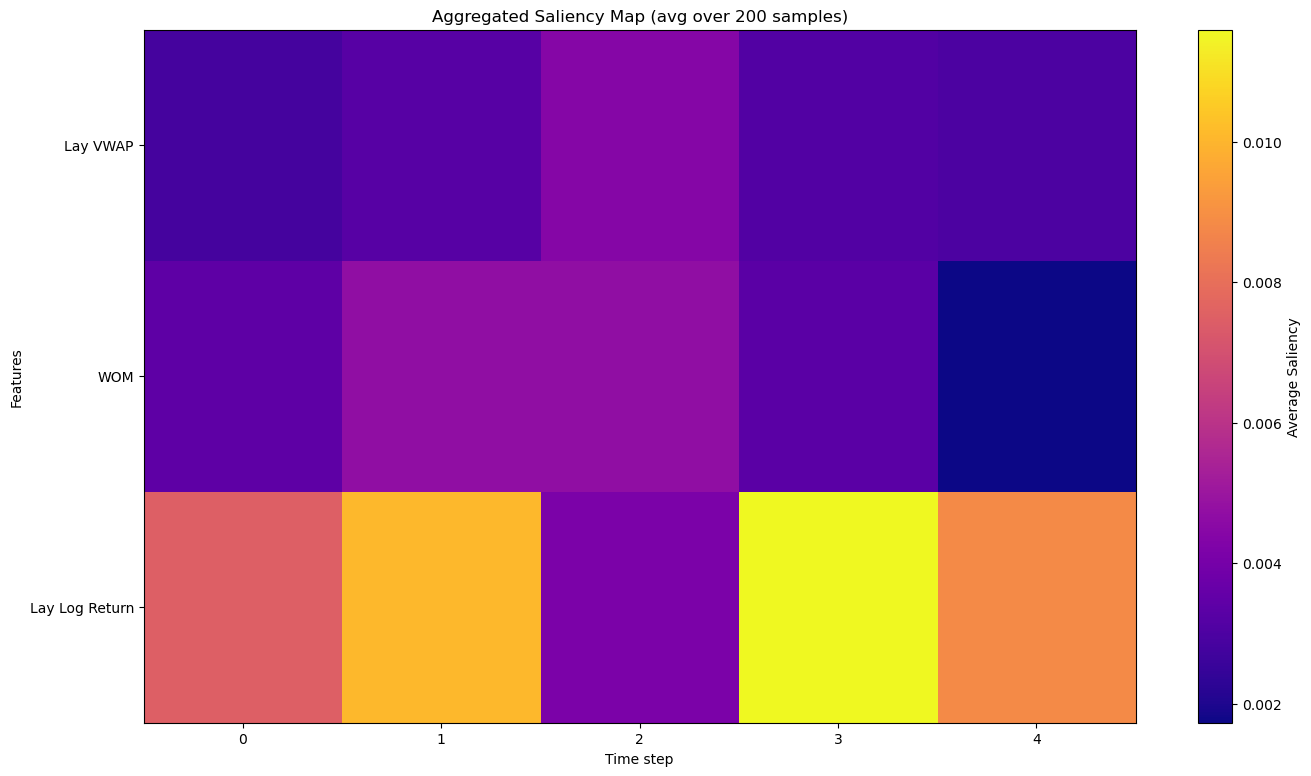

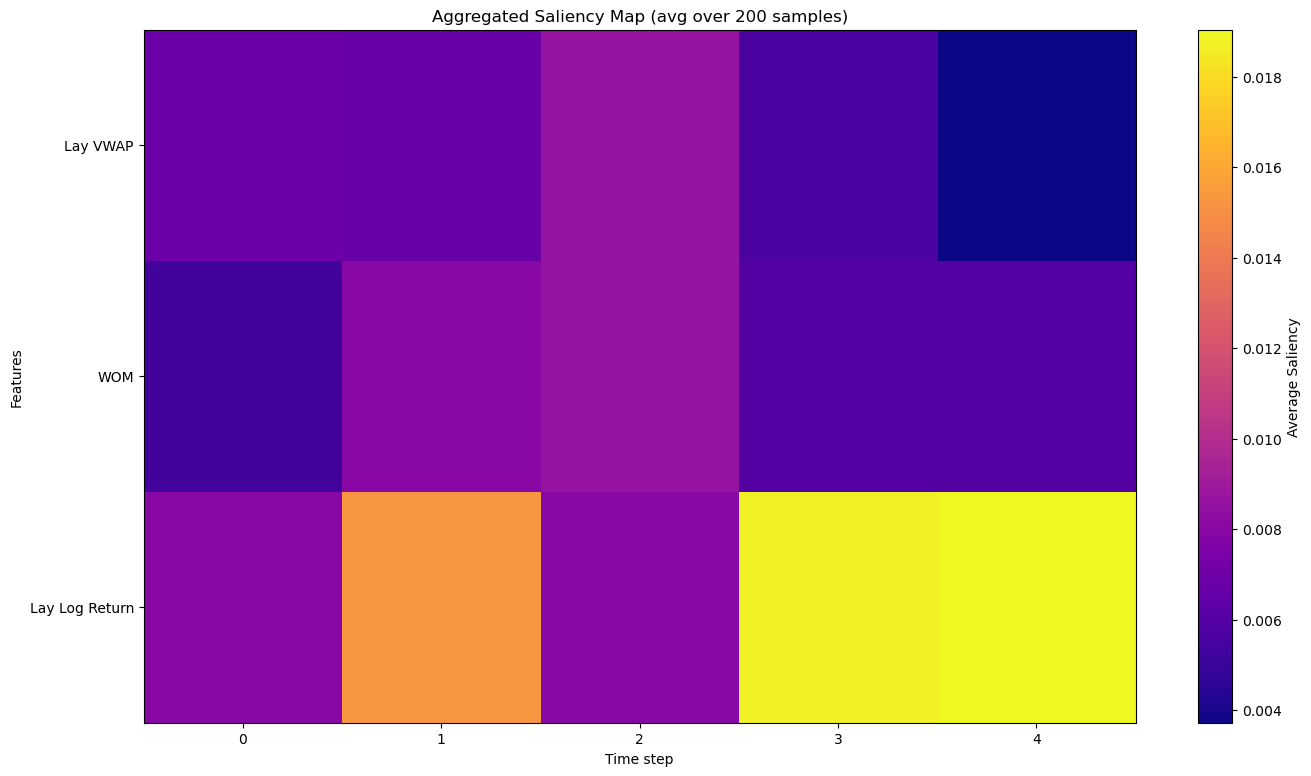

In [11]:
CNN_LSTM_Explain(back_results['model'], back_results['X_test'],'task1_b', ['Lay VWAP', 'WOM', 'Lay Log Return'])
CNN_LSTM_Explain(lay_results['model'], lay_results['X_test'],'task1_l', ['Lay VWAP', 'WOM', 'Lay Log Return'])

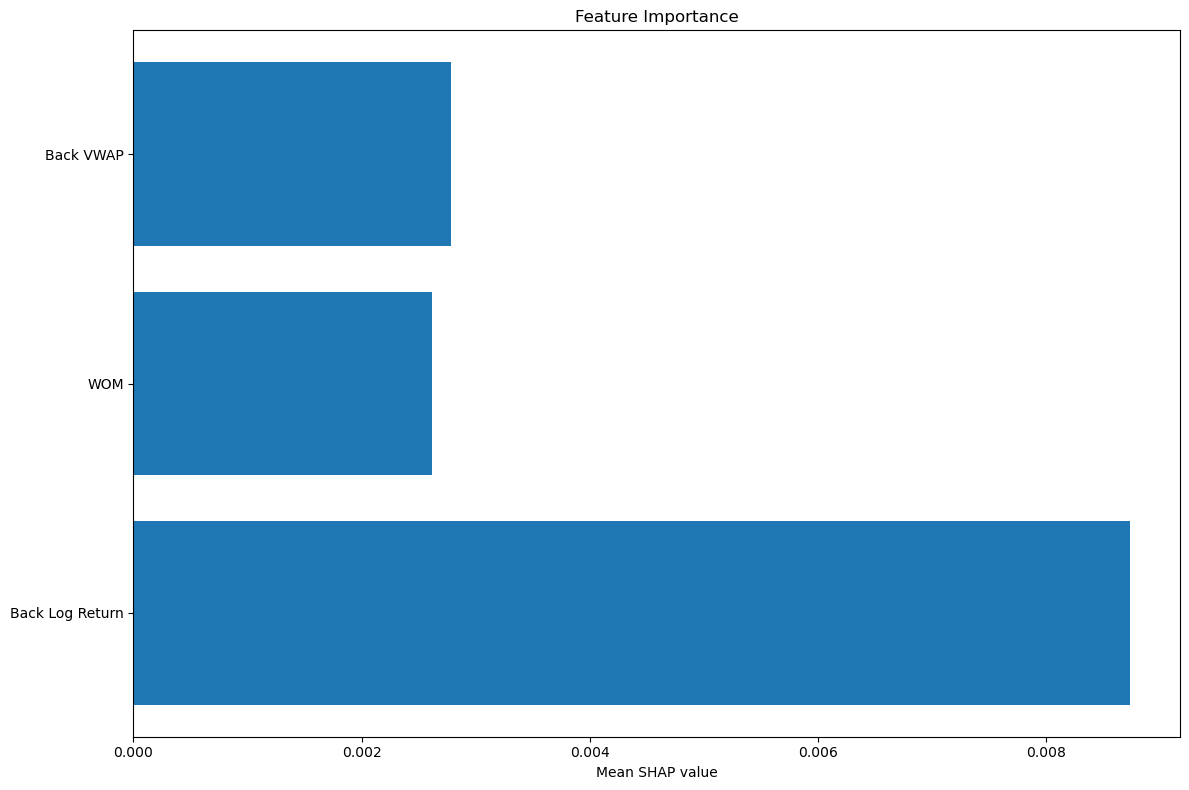

'\\begin{table}[h!]\n\\begin{tabular}{lr}\n\\toprule\nfeature_names & feature_importance (%) \\\\\n\\midrule\nBack VWAP & 19.7 \\\\\nWOM & 18.5 \\\\\nBack Log Return & 61.8 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [12]:
feature_importance_table(back_XGBoost_results['model'], back_XGBoost_results['X_test'], ['Back VWAP', 'WOM', 'Back Log Return'])

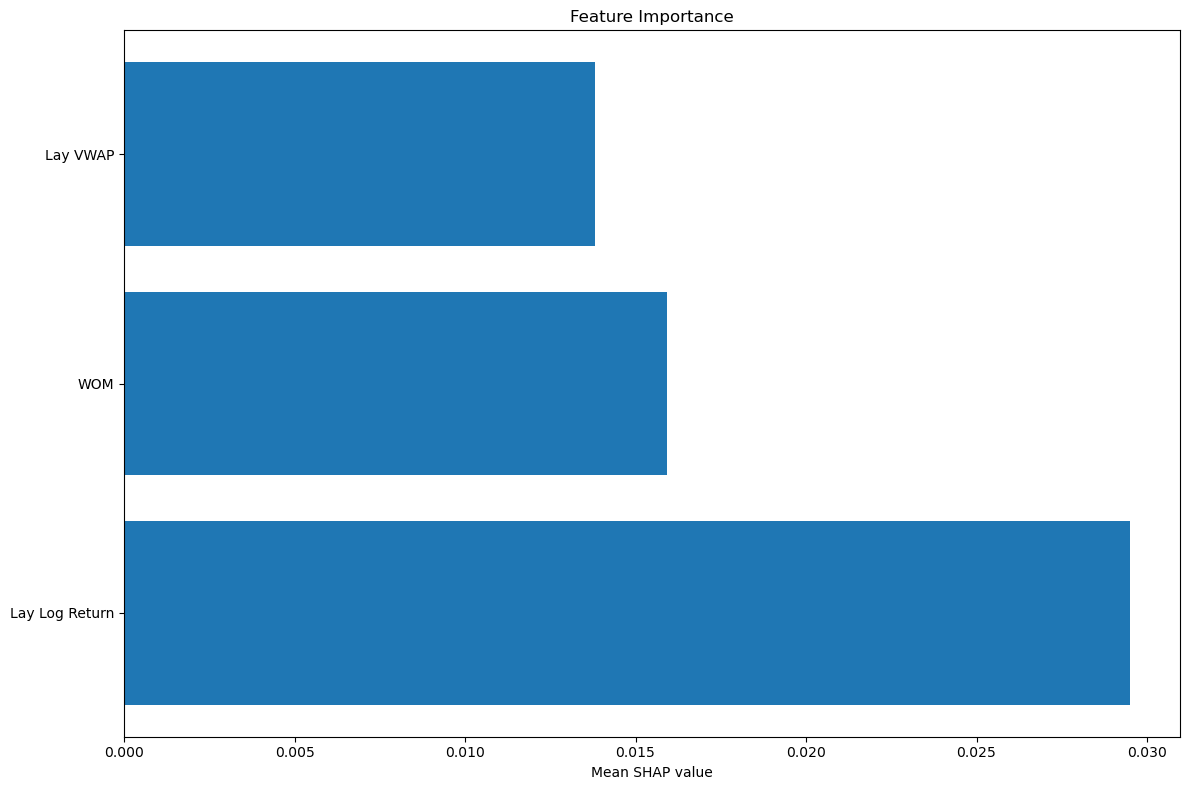

'\\begin{table}[h!]\n\\begin{tabular}{lr}\n\\toprule\nfeature_names & feature_importance (%) \\\\\n\\midrule\nLay VWAP & 23.3 \\\\\nWOM & 26.9 \\\\\nLay Log Return & 49.8 \\\\\n\\bottomrule\n\\end{tabular}\n\\end{table}\n'

In [13]:
feature_importance_table(lay_XGBoost_results['model'], lay_XGBoost_results['X_test'], ['Lay VWAP', 'WOM', 'Lay Log Return'])